## 1. Global Parameter

In [13]:
params = {
    'symbol_rate': 1e6,
    'sps': 8,
    'rolloff': 0.35,
    'modulation': 'QPSK',
    'num_bits': 10000,
    'filter_span': 10
}

## 2. Import Packages

In [14]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Data Generation

  Generate an 1-bit-array randomly with 0/1.<br>
  Output：1-dimension array of 10000-element.

In [15]:
# Generate random source bits (0 or 1)
tx_bits = np.random.randint(0, 2, params['num_bits'])

print(tx_bits)

[0 0 1 ... 1 0 0]


## 4. Symbol-Mapping - QPSK

In [16]:
# Group bits into pairs for QPSK (2 bits per symbol)
bits_reshaped = tx_bits.reshape(-1, 2)

# Map bits to BPSK levels: 0 -> -1, 1 -> 1 for I and Q channels
i_channel = bits_reshaped[:, 0] * 2 - 1
q_channel = bits_reshaped[:, 1] * 2 - 1

# Combine I and Q to form complex QPSK symbols and normalize energy to 1
tx_symbols = (i_channel + 1j * q_channel) / np.sqrt(2)

print(tx_symbols)

[-0.70710678-0.70710678j  0.70710678+0.70710678j  0.70710678+0.70710678j
 ...  0.70710678-0.70710678j  0.70710678+0.70710678j
 -0.70710678-0.70710678j]


## 5. Upsampling & Pulse Shaping

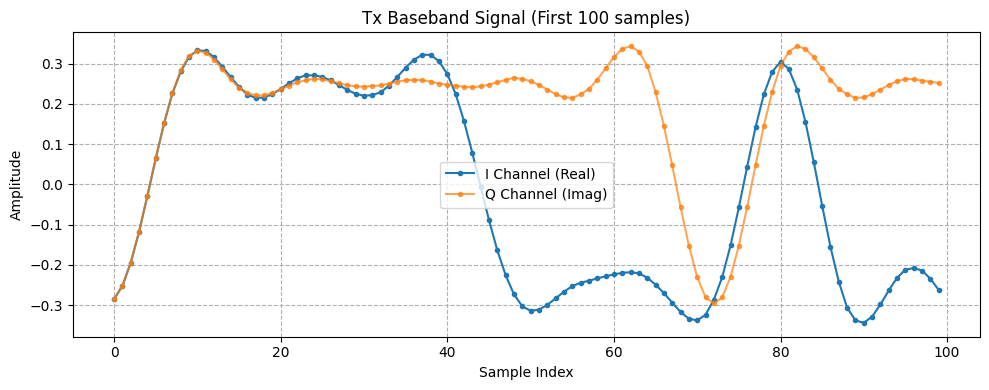

--- Status ---
tx_bits shape: (10000,), dtype: int64
tx_symbols shape: (5000,), dtype: complex128
tx_baseband_signal shape: (40000,), dtype: complex128


In [17]:
def get_rrc_filter(span, sps, beta):
  # Create a time vector centered at zero
  t = np.arange(-span/2, span/2 + 1/sps, 1/sps)
  # Root-Raised Cosine mathematical formula implementation
  with np.errstate(divide='ignore', invalid='ignore'):
    h = (np.sin(np.pi * t * (1 - beta)) + 4 * beta * t * np.cos(np.pi * t * (1 + beta))) / \
            (np.pi * t * (1 - (4 * beta * t)**2))

  # Handle the singularity at t=0
  h[t == 0] = 1 - beta + (4 * beta / np.pi)
  # Handle singularities at t = +/- 1/(4*beta)
  if beta != 0:
        edge_val = beta / np.sqrt(2) * ((1 + 2/np.pi) * np.sin(np.pi/(4*beta)) + (1 - 2/np.pi) * np.cos(np.pi/(4*beta)))
        h[np.isclose(np.abs(t), 1/(4*beta))] = edge_val

  # Normalize filter coefficients to unit energy
  h = h / np.sqrt(np.sum(h**2))
  return h

# Generate the RRC filter based on parameters
rrc_filter = get_rrc_filter(params['filter_span'], params['sps'], params['rolloff'])

# Initialize upsampled array with zeros (zero-padding)
upsampled_symbols = np.zeros(len(tx_symbols) * params['sps'], dtype=complex)
# Insert symbols every 'sps' (Samples Per Symbol) interval
upsampled_symbols[::params['sps']] = tx_symbols

# Perform convolution between upsampled symbols and the RRC filter to get the baseband signal
tx_baseband_signal = np.convolve(upsampled_symbols, rrc_filter, mode='same')

# Visualization
plt.figure(figsize=(10, 4))
plt.plot(np.real(tx_baseband_signal[:100]), label='I Channel (Real)', marker='.')
plt.plot(np.imag(tx_baseband_signal[:100]), label='Q Channel (Imag)', marker='.', alpha=0.7)
plt.title('Tx Baseband Signal (First 100 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# Print summary of the current state
print(f"--- Status ---")
print(f"tx_bits shape: {tx_bits.shape}, dtype: {tx_bits.dtype}")
print(f"tx_symbols shape: {tx_symbols.shape}, dtype: {tx_symbols.dtype}")
print(f"tx_baseband_signal shape: {tx_baseband_signal.shape}, dtype: {tx_baseband_signal.dtype}")

## 6. Export Data to Google Sheets
This section authenticates your Google account and saves the generated `tx_bits` to the spreadsheet `SDR_datasheet`.

In [19]:
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
import numpy as np

# Authenticate the user
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Define the spreadsheet name
spreadsheet_name = 'SDR_datasheet'

try:
    # Open the spreadsheet
    sh = gc.open(spreadsheet_name)
    worksheet = sh.get_worksheet(0)
    worksheet.clear()

    # Prepare data subsets and convert to standard Python types to avoid serialization errors
    # Column A: tx_bits (first 100) as standard integers
    bits_sub = [int(x) for x in tx_bits[:100]]

    # Column B: tx_symbols (first 50) as strings
    syms_sub = [str(x) for x in tx_symbols[:50]]

    # Column C: tx_baseband_signal (first 400) as strings
    base_sub = [str(x) for x in tx_baseband_signal[:400]]

    # Determine maximum length to align columns
    max_len = max(len(bits_sub), len(syms_sub), len(base_sub))

    # Helper to pad lists to the same length with empty strings
    def pad_list(lst, length):
        return list(lst) + [''] * (length - len(lst))

    # Create combined DataFrame for columns A, B, and C
    data = {
        'tx_bits': pad_list(bits_sub, max_len),
        'tx_symbols': pad_list(syms_sub, max_len),
        'tx_baseband_signal': pad_list(base_sub, max_len)
    }
    df_combined = pd.DataFrame(data)

    # Update the worksheet starting from A1
    # We convert the dataframe to a list of lists including the header
    output_data = [df_combined.columns.values.tolist()] + df_combined.values.tolist()
    worksheet.update(output_data)

    print(f"Successfully updated {spreadsheet_name} columns A, B, and C.")
except gspread.exceptions.SpreadsheetNotFound:
    print(f"Error: Spreadsheet '{spreadsheet_name}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully updated SDR_datasheet columns A, B, and C.
